# Notebook 02 — Extended EDA & Regression Modeling

**Project:** SNAP Participation and Food Access  
**Data:** USDA Food Access Research Atlas (2019)  
**Research question:** Are census tracts with higher SNAP participation more likely to experience low supermarket access, and does this relationship differ between urban and rural areas?

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import ttest_ind, probplot
from scipy.stats import f as f_dist
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
from pathlib import Path

warnings.filterwarnings('ignore')

DATA = Path('..') / 'data' / 'cleaned'
FIGURES = Path('..') / 'figures'
FIGURES.mkdir(exist_ok=True)

## 1. Load Data

In [2]:
df_model = pd.read_csv(DATA / 'food_access_modeling.csv')
print(f'Modeling dataset: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns')
df_model.head(3)

Modeling dataset: 42,156 rows x 26 columns


,CensusTract,State,County,Urban,urban_label,Pop2010,OHU2010,PovertyRate,MedianFamilyIncome,log_median_family_income,...,log_response,pct_children,pct_seniors,pct_white,pct_black,pct_asian,pct_hispanic,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle
0,1001020100,Alabama,Autauga County,1,Urban,1912,693,11.336453,81250.0,11.305286,...,3.223299,26.516736,11.558577,84.832636,11.349372,0.732218,2.301255,0,0,0
1,1001020200,Alabama,Autauga County,1,Urban,2170,743,17.876788,49000.0,10.799576,...,3.361387,27.926267,9.861751,40.921659,56.082949,0.230415,3.456221,1,1,0
2,1001020300,Alabama,Autauga County,1,Urban,3373,1256,15.046030,62609.0,11.044664,...,2.719919,26.504595,13.015120,76.371183,19.181737,0.504002,2.579306,0,0,0


---
## 2. Extended EDA

### Fig 6 — Correlation Heatmap

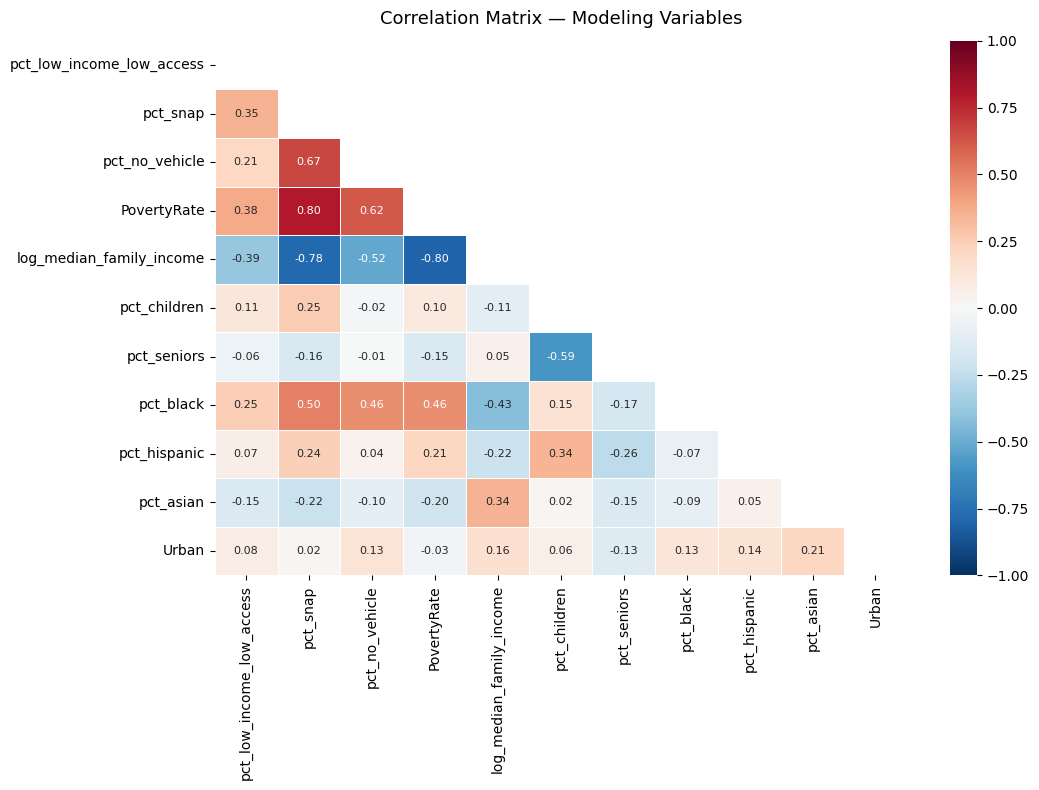

In [3]:
corr_cols = [
    'pct_low_income_low_access', 'pct_snap', 'pct_no_vehicle',
    'PovertyRate', 'log_median_family_income',
    'pct_children', 'pct_seniors', 'pct_black', 'pct_hispanic', 'pct_asian',
    'Urban',
]
corr = df_model[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix — Modeling Variables', fontsize=13, pad=12)
plt.tight_layout()
fig.savefig(FIGURES / '06_correlation_heatmap.png', dpi=150)
plt.show()

`PovertyRate` and `log_median_family_income` correlate at −0.81, which is strong enough to cause multicollinearity if both are included. Models A and C use income, and Model B uses poverty rate as a robustness check.

### Fig 7 — Urban vs Rural Distributions

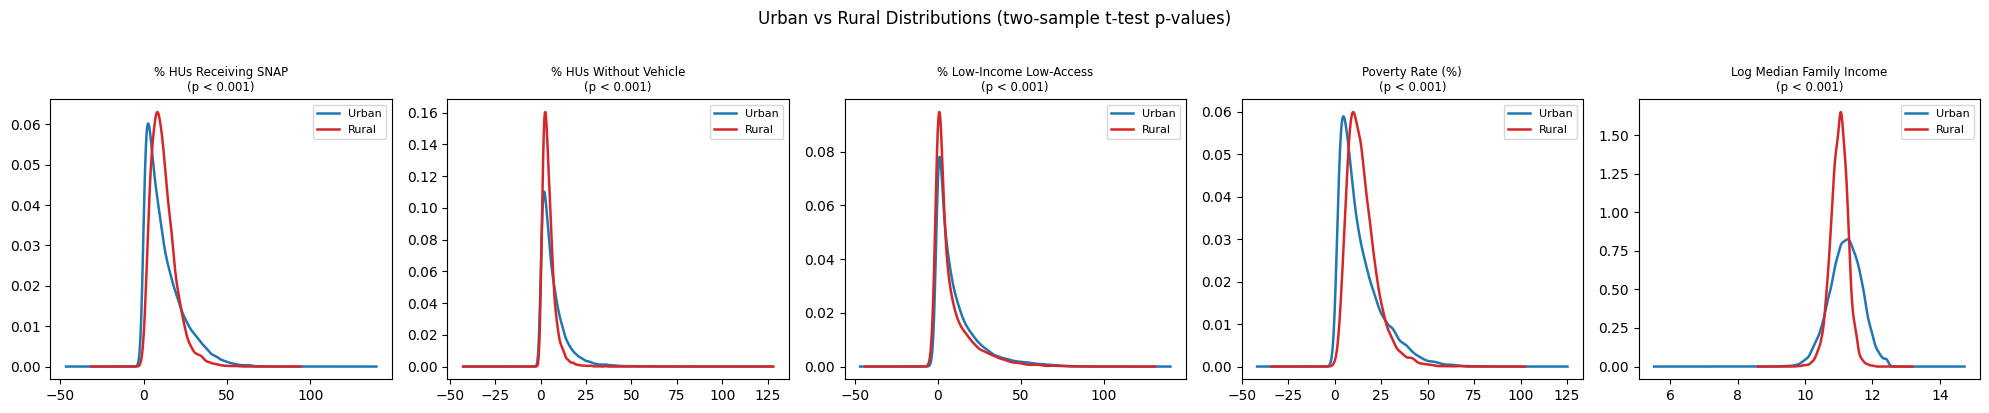

In [4]:
key_vars = {
    'pct_snap': '% HUs Receiving SNAP',
    'pct_no_vehicle': '% HUs Without Vehicle',
    'pct_low_income_low_access': '% Low-Income Low-Access',
    'PovertyRate': 'Poverty Rate (%)',
    'log_median_family_income': 'Log Median Family Income',
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
palette = {'Urban': '#1f77b4', 'Rural': '#d62728'}

for ax, (col, label) in zip(axes, key_vars.items()):
    for group, color in palette.items():
        subset = df_model.loc[df_model['urban_label'] == group, col].dropna()
        subset.plot.kde(ax=ax, label=group, color=color, linewidth=1.8)
    u_vals = df_model.loc[df_model['urban_label'] == 'Urban', col].dropna()
    r_vals = df_model.loc[df_model['urban_label'] == 'Rural', col].dropna()
    _, p = ttest_ind(u_vals, r_vals, equal_var=False)
    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.set_title(f'{label}\n({p_str})', fontsize=8.5)
    ax.set_ylabel('')
    ax.legend(fontsize=8)

plt.suptitle('Urban vs Rural Distributions (two-sample t-test p-values)', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / '07_urban_rural_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

All five variables differ significantly between urban and rural tracts (all p < 0.001), justifying `Urban` as a predictor and motivating the interaction model.

### Fig 8 — Log Transformation Justification

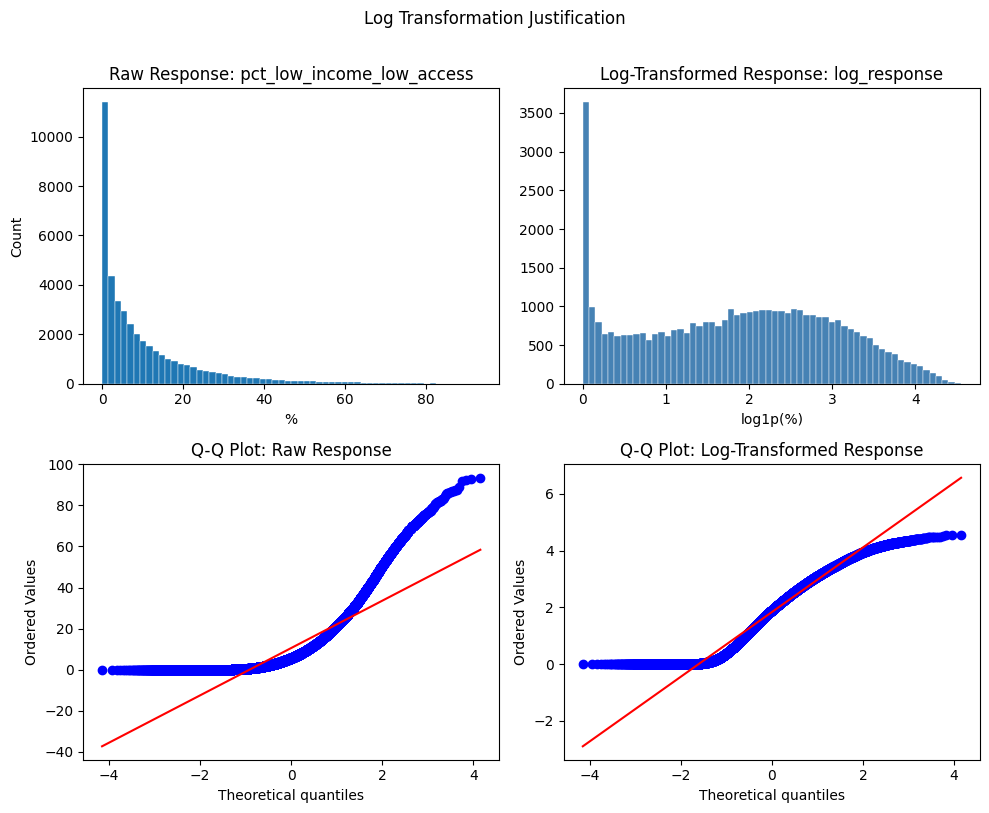

Raw skewness:             2.043
Log-transformed skewness: -0.002


In [5]:
raw  = df_model['pct_low_income_low_access'].dropna()
logv = df_model['log_response'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(raw, bins=60, edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('Raw Response: pct_low_income_low_access')
axes[0, 0].set_xlabel('%')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(logv, bins=60, edgecolor='white', linewidth=0.3, color='steelblue')
axes[0, 1].set_title('Log-Transformed Response: log_response')
axes[0, 1].set_xlabel('log1p(%)')

probplot(raw, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Raw Response')

probplot(logv, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Log-Transformed Response')

plt.suptitle('Log Transformation Justification', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / '08_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Raw skewness:             {raw.skew():.3f}')
print(f'Log-transformed skewness: {logv.skew():.3f}')

The raw response is heavily right-skewed, log1p brings it much closer to symmetric (see skewness values above). All regression models use `log_response` as the dependent variable.

### Fig 9 — SNAP vs Low-Access by Income Quartile

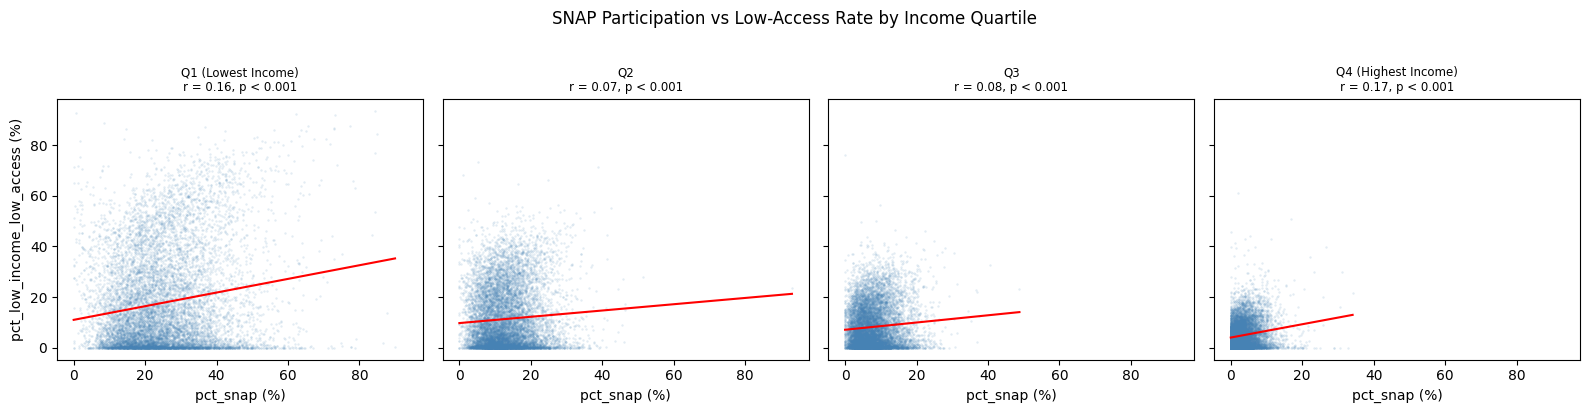

In [6]:
df_model['income_quartile'] = pd.qcut(
    df_model['MedianFamilyIncome'], q=4,
    labels=['Q1 (Lowest Income)', 'Q2', 'Q3', 'Q4 (Highest Income)']
)

quartiles = ['Q1 (Lowest Income)', 'Q2', 'Q3', 'Q4 (Highest Income)']
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True, sharex=True)

for ax, q in zip(axes, quartiles):
    sub = df_model[df_model['income_quartile'] == q].dropna(
        subset=['pct_snap', 'pct_low_income_low_access']
    )
    ax.scatter(sub['pct_snap'], sub['pct_low_income_low_access'],
               alpha=0.15, s=3, linewidths=0, color='steelblue')
    x, y = sub['pct_snap'].values, sub['pct_low_income_low_access'].values
    m, b, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.set_title(f'{q}\nr = {r:.2f}, {p_str}', fontsize=8.5)
    ax.set_xlabel('pct_snap (%)')

axes[0].set_ylabel('pct_low_income_low_access (%)')
plt.suptitle('SNAP Participation vs Low-Access Rate by Income Quartile', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / '09_snap_lila_by_income_quartile.png', dpi=150, bbox_inches='tight')
plt.show()

The positive SNAP–LILA association holds across all income quartiles, showing it is not simply from income confounding.

### Fig 10 — Low-Access Rate by Racial Majority of Tract

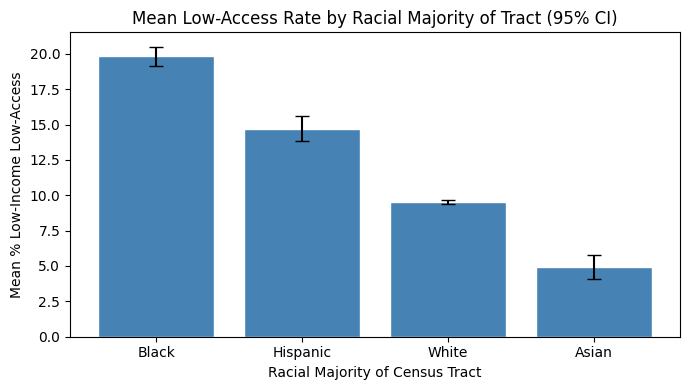

racial_majority  count      mean
          Black   3605 19.826633
       Hispanic   1740 14.717364
          White  36489  9.512424
          Asian    322  4.932153


In [7]:
racial_cols = ['pct_white', 'pct_black', 'pct_hispanic', 'pct_asian']
df_model['racial_majority'] = (
    df_model[racial_cols].idxmax(axis=1)
    .str.replace('pct_', '').str.title()
)

demo = (
    df_model.groupby('racial_majority')['pct_low_income_low_access']
    .agg(['mean', 'count', 'sem'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    demo['racial_majority'], demo['mean'],
    yerr=1.96 * demo['sem'],
    capsize=5, color='steelblue', edgecolor='white'
)
ax.set_xlabel('Racial Majority of Census Tract')
ax.set_ylabel('Mean % Low-Income Low-Access')
ax.set_title('Mean Low-Access Rate by Racial Majority of Tract (95% CI)')
plt.tight_layout()
fig.savefig(FIGURES / '10_demographics_lila.png', dpi=150)
plt.show()

print(demo[['racial_majority', 'count', 'mean']].to_string(index=False))

Tracts with Black or Hispanic majorities have higher mean LILA rates. Racial composition is included as a control variable in all regression models.

---
## 3. Regression Modeling

**Response:** `log_response` (log1p of `pct_low_income_low_access`), justified above.

**Excluded variables:** `LILATracts_*` (derived from the response), `LowIncomeTracts` (redundant with `PovertyRate`), `TractSNAP`/`TractHUNV` (raw counts, use % versions), `pct_white` (reference category for racial composition).

**Multicollinearity:** `PovertyRate` and `log_median_family_income` correlate at −0.81, so they are never included together. Model A uses income, Model B uses poverty rate.

**Standard errors:** Clustered at State level to handle within-state spatial autocorrelation.

### Model A — Main Effects (income as socioeconomic control)

In [8]:
formula_A = (
    'log_response ~ pct_snap + log_median_family_income'
    ' + pct_no_vehicle + Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_A = smf.ols(formula_A, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
print(model_A.summary())

                            OLS Regression Results                            
Dep. Variable:           log_response   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     169.9
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           2.66e-34
Time:                        18:37:29   Log-Likelihood:                -63180.
No. Observations:               42156   AIC:                         1.264e+05
Df Residuals:                   42146   BIC:                         1.265e+05
Df Model:                           9                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Model B — Main Effects (poverty rate as socioeconomic control)

Replaces `log_median_family_income` with `PovertyRate` as a robustness check. In Model B, `pct_snap` becomes significant, reflecting that income absorbs much of the SNAP signal in Model A (SNAP eligibility is income-based, so the two are highly correlated).

In [9]:
formula_B = (
    'log_response ~ pct_snap + PovertyRate'
    ' + pct_no_vehicle + Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_B = smf.ols(formula_B, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
print(model_B.summary())

                            OLS Regression Results                            
Dep. Variable:           log_response   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     163.2
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           6.95e-34
Time:                        18:37:29   Log-Likelihood:                -63552.
No. Observations:               42156   AIC:                         1.271e+05
Df Residuals:                   42146   BIC:                         1.272e+05
Df Model:                           9                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.5804      0.078      7.

### Model C — Interaction Model

Adds `pct_snap:Urban` and `pct_no_vehicle:Urban`. The `pct_snap:Urban` coefficient directly tests whether the SNAP–LILA association differs between urban and rural tracts.

In [10]:
formula_C = (
    'log_response ~ pct_snap + log_median_family_income'
    ' + pct_no_vehicle + Urban'
    ' + pct_snap:Urban + pct_no_vehicle:Urban'
    ' + pct_children + pct_seniors'
    ' + pct_black + pct_hispanic + pct_asian'
)

model_C = smf.ols(formula_C, data=df_model).fit(
    cov_type='cluster', cov_kwds={'groups': df_model['State']}
)
print(model_C.summary())

                            OLS Regression Results                            
Dep. Variable:           log_response   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     224.7
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           1.47e-38
Time:                        18:37:29   Log-Likelihood:                -63107.
No. Observations:               42156   AIC:                         1.262e+05
Df Residuals:                   42144   BIC:                         1.263e+05
Df Model:                          11                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Variance Inflation Factors

Checked on the Model A predictors.

In [11]:
X_vif = df_model[[
    'pct_snap', 'log_median_family_income', 'pct_no_vehicle',
    'Urban', 'pct_children', 'pct_seniors',
    'pct_black', 'pct_hispanic', 'pct_asian'
]].dropna().copy()
X_vif['const'] = 1.0

vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_df[vif_df['Variable'] != 'const'].to_string(index=False))

                Variable      VIF
                pct_snap 4.039573
log_median_family_income 3.172986
          pct_no_vehicle 2.101404
            pct_children 1.791413
             pct_seniors 1.636105
               pct_black 1.577212
            pct_hispanic 1.350655
               pct_asian 1.220336
                   Urban 1.218577


### Model Comparison

In [12]:
comparison = summary_col(
    [model_A, model_B, model_C],
    model_names=['Model A\n(income)', 'Model B\n(poverty)', 'Model C\n(interactions)'],
    stars=True,
    float_format='%.4f',
    info_dict={
        'AIC': lambda x: f'{x.aic:.1f}',
        'Observations': lambda x: f'{int(x.nobs):,}',
    }
)
print(comparison)


                          Model A    Model B      Model C    
                          (income)  (poverty)  (interactions)
-------------------------------------------------------------
Intercept                10.7487*** 0.5804***  10.6798***    
                         (0.4020)   (0.0781)   (0.3905)      
pct_snap                 0.0026     0.0099***  -0.0146**     
                         (0.0018)   (0.0021)   (0.0058)      
log_median_family_income -0.8707***            -0.8588***    
                         (0.0364)              (0.0355)      
pct_no_vehicle           -0.0269*** -0.0326*** 0.0129        
                         (0.0027)   (0.0030)   (0.0117)      
Urban                    0.6698***  0.5655***  0.6349***     
                         (0.0630)   (0.0637)   (0.0877)      
pct_children             0.0169***  0.0182***  0.0153***     
                         (0.0023)   (0.0025)   (0.0023)      
pct_seniors              0.0079***  0.0127***  0.0079***     
       

#### F-test: do the interaction terms in Model C jointly improve fit over Model A?

$H_0$: pct_snap:Urban = 0 and pct_no_vehicle:Urban = 0

In [ ]:
r2_A = model_A.rsquared
r2_C = model_C.rsquared
n = int(model_C.nobs)
q = 2
k = int(model_C.df_model)

f_stat = ((r2_C - r2_A) / q) / ((1 - r2_C) / (n - k - 1))
p_val = 1 - f_dist.cdf(f_stat, q, n - k - 1)

print('F-test: Model A vs Model C')
print('H0: interaction terms are jointly zero')
print(f'F({q}, {n - k - 1}) = {f_stat:.3f}')
print(f'p-value = {p_val:.2e}')

F-test: Model A vs Model C
H0: interaction terms are jointly zero
F(2, 42144) = 73.520
p-value = 1.11e-16


### Fig 11 — Model C Coefficient Plot

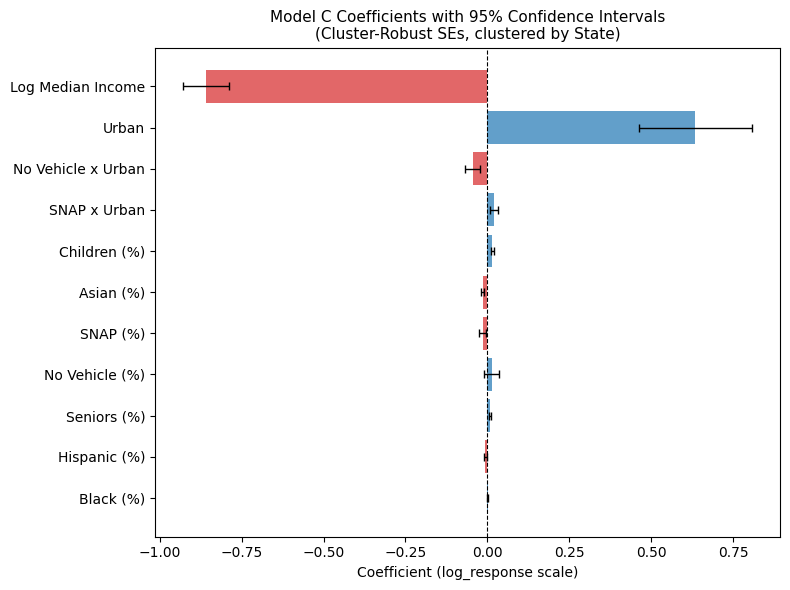

In [14]:
rename = {
    'pct_snap': 'SNAP (%)',
    'log_median_family_income': 'Log Median Income',
    'pct_no_vehicle': 'No Vehicle (%)',
    'Urban': 'Urban',
    'pct_children': 'Children (%)',
    'pct_seniors': 'Seniors (%)',
    'pct_black': 'Black (%)',
    'pct_hispanic': 'Hispanic (%)',
    'pct_asian': 'Asian (%)',
    'pct_snap:Urban': 'SNAP x Urban',
    'Urban:pct_snap': 'SNAP x Urban',
    'pct_no_vehicle:Urban': 'No Vehicle x Urban',
    'Urban:pct_no_vehicle': 'No Vehicle x Urban',
}

coef = model_C.params.drop('Intercept')
ci = model_C.conf_int().drop('Intercept')
coef.index = [rename.get(i, i) for i in coef.index]
ci.index = coef.index

order = coef.abs().sort_values().index
coef, ci = coef[order], ci.loc[order]

pt_colors = ['#d62728' if v < 0 else '#1f77b4' for v in coef]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(coef)), coef.values, color=pt_colors, alpha=0.7)
ax.errorbar(
    coef.values, range(len(coef)),
    xerr=[(coef.values - ci[0].values), (ci[1].values - coef.values)],
    fmt='none', color='black', capsize=3, linewidth=1
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(coef)))
ax.set_yticklabels(coef.index, fontsize=10)
ax.set_xlabel('Coefficient (log_response scale)')
ax.set_title(
    'Model C Coefficients with 95% Confidence Intervals\n'
    '(Cluster-Robust SEs, clustered by State)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(FIGURES / '11_coefficient_plot.png', dpi=150)
plt.show()